In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("Walmart.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [4]:
df.shape

(6435, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [6]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [7]:
# IQR
Q1 = df['Weekly_Sales'].quantile(0.25)
Q3 = df['Weekly_Sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print('Weekly Sales IQR:', IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print()
print("------------------")

Q1 = df['Temperature'].quantile(0.25)
Q3 = df['Temperature'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print('Temperature IQR:', IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print()
print("------------------")
Q1 = df['Fuel_Price'].quantile(0.25)
Q3 = df['Fuel_Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print('Fuel Price IQR:', IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print()
print("------------------")
Q1 = df['CPI'].quantile(0.25)
Q3 = df['CPI'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print('CPI IQR:', IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print()
print("------------------")
Q1 = df['Unemployment'].quantile(0.25)
Q3 = df['Unemployment'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print('Unemployment IQR:', IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Weekly Sales IQR: 866808.5549999999
Lower Bound: -746862.7275
Upper Bound: 2720371.4924999997

------------------
Temperature IQR: 27.479999999999997
Lower Bound: 6.240000000000002
Upper Bound: 116.16

------------------
Fuel Price IQR: 0.802
Lower Bound: 1.7299999999999998
Upper Bound: 4.938

------------------
CPI IQR: 81.00829345
Lower Bound: 10.222559825000019
Upper Bound: 334.255733625

------------------
Unemployment IQR: 1.7309999999999999
Lower Bound: 4.2945
Upper Bound: 11.218499999999999


In [8]:
df['Store'].nunique()

45

In [9]:
df['Holiday_Flag'].value_counts()

,count
Holiday_Flag,
0,5985
1,450


In [10]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [11]:
df.duplicated().sum()

np.int64(0)

## OUTLIER ANALYSIS

In [12]:
df.head(2)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106


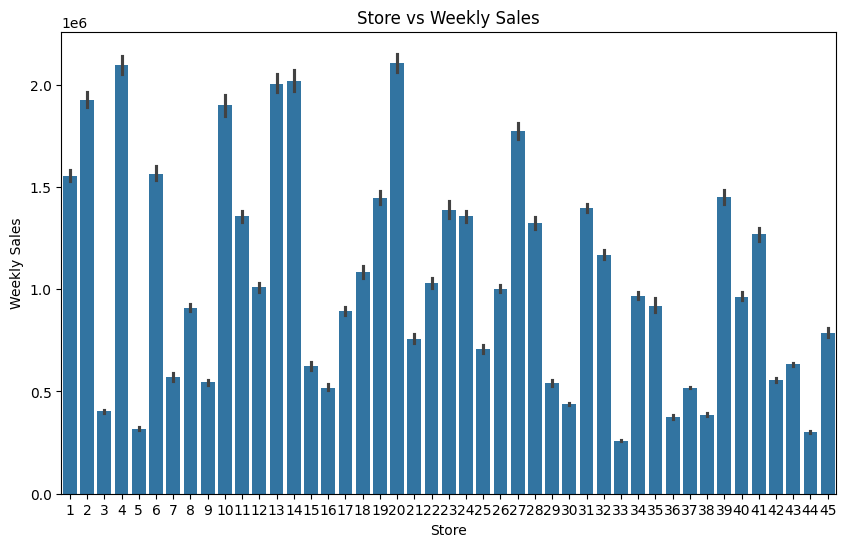

In [13]:
# Store And Weekly Sales
plt.figure(figsize=(10, 6))
sns.barplot(x='Store', y='Weekly_Sales', data=df)
plt.title('Store vs Weekly Sales')
plt.xlabel('Store')
plt.ylabel('Weekly Sales')
plt.show()

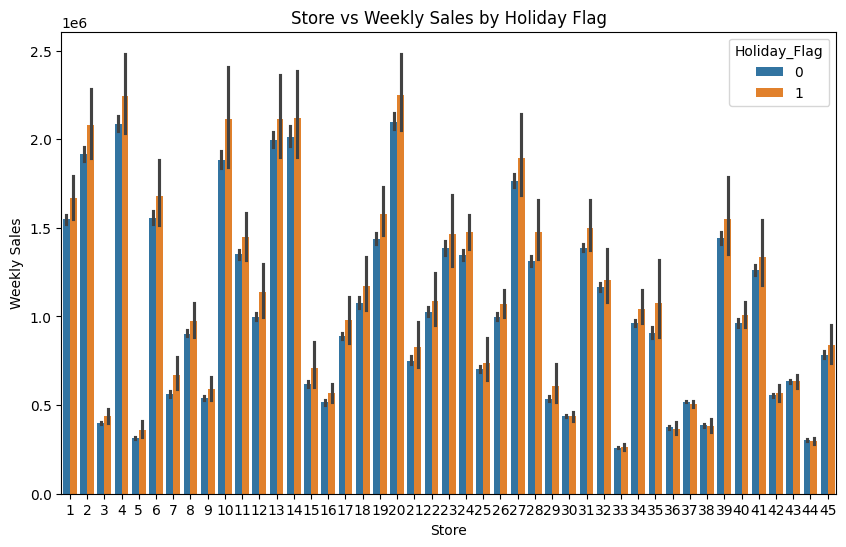

In [14]:
# Store and Holiday
plt.figure(figsize=(10, 6))
sns.barplot(x='Store', hue='Holiday_Flag', y='Weekly_Sales', data=df)
plt.title('Store vs Weekly Sales by Holiday Flag')
plt.xlabel('Store')
plt.ylabel('Weekly Sales')
plt.show()

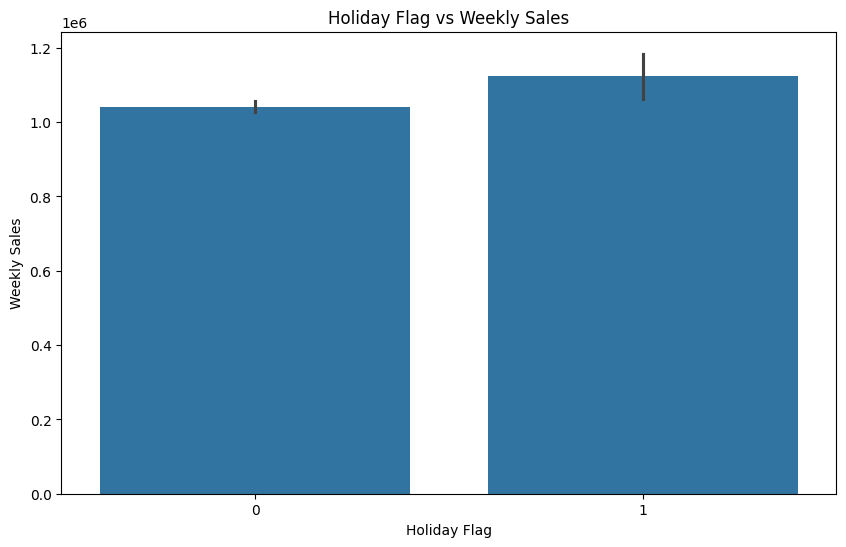

In [15]:
# Holiday Flag and Weekly Sales
plt.figure(figsize=(10, 6))
sns.barplot(x='Holiday_Flag', y='Weekly_Sales', data=df)
plt.title('Holiday Flag vs Weekly Sales')
plt.xlabel('Holiday Flag')
plt.ylabel('Weekly Sales')
plt.show()

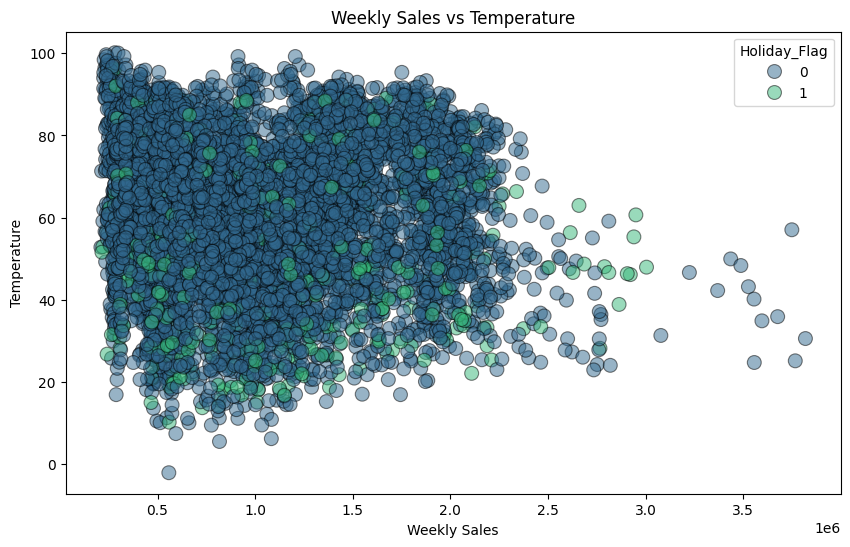

In [16]:
#  Temperature and Weekly Sales
plt.figure(figsize=(10, 6))
sns.scatterplot(y='Temperature', x='Weekly_Sales', data=df, color='blue', alpha=0.5, edgecolor='black', s=100, marker='o', hue='Holiday_Flag', palette='viridis')
plt.title('Weekly Sales vs Temperature')
plt.ylabel('Temperature')
plt.xlabel('Weekly Sales')
plt.show()

#### Q1 If the weekly sales are affected by the unemployment rate, if yes - which stores are suffering the most?



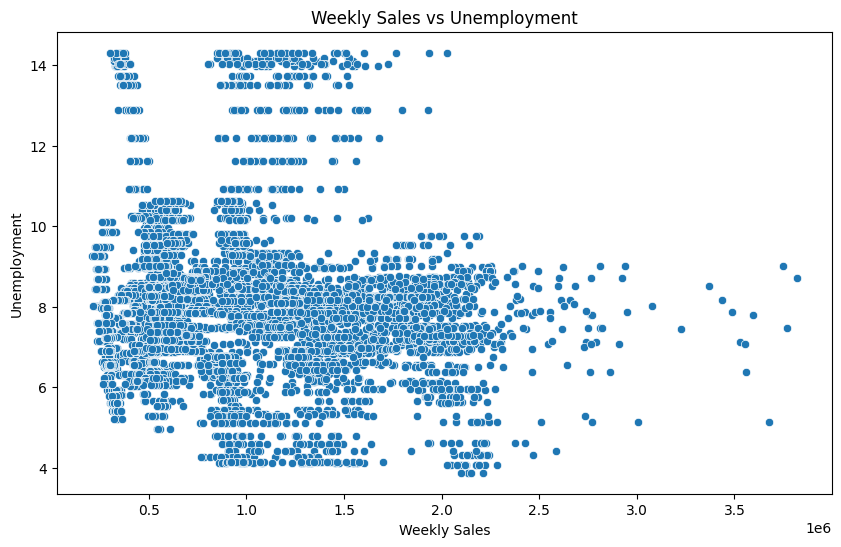

In [17]:

# Unemployment and Weekly Sales
plt.figure(figsize=(10, 6))
sns.scatterplot(y='Unemployment', x='Weekly_Sales', data=df)
plt.title('Weekly Sales vs Unemployment')
plt.ylabel('Unemployment')
plt.xlabel('Weekly Sales')
plt.show()

In [18]:
empo = df['Unemployment']
empo

,Unemployment
0,8.106
1,8.106
2,8.106
3,8.106
4,8.106
...,...
6430,8.684
6431,8.667
6432,8.667
6433,8.667


In [19]:
empo = empo.drop_duplicates().T
empo

,Unemployment
0,8.106
8,7.808
21,7.787
34,7.838
48,7.742
...,...
6209,6.906
6236,6.078
6249,5.774
6275,5.407


In [20]:
empo1 = empo.round(0)


In [21]:
empo1

,Unemployment
0,8.0
8,8.0
21,8.0
34,8.0
48,8.0
...,...
6209,7.0
6236,6.0
6249,6.0
6275,5.0


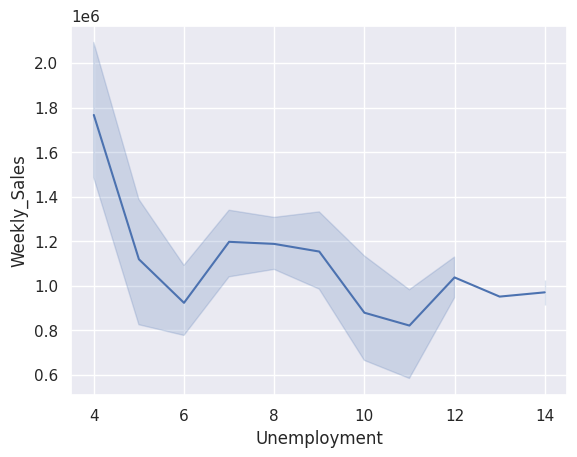

In [22]:
sns.set(style = "darkgrid")
sns.lineplot(x = empo1, y = "Weekly_Sales", data = df);

### canclusion: The unemployment rate does not seem to have a significant impact on weekly sales,as the line plot shows no clear trend or correlation between the two variables.

### Q2 If the weekly sales show a seasonal trend, when and what could be the reason?

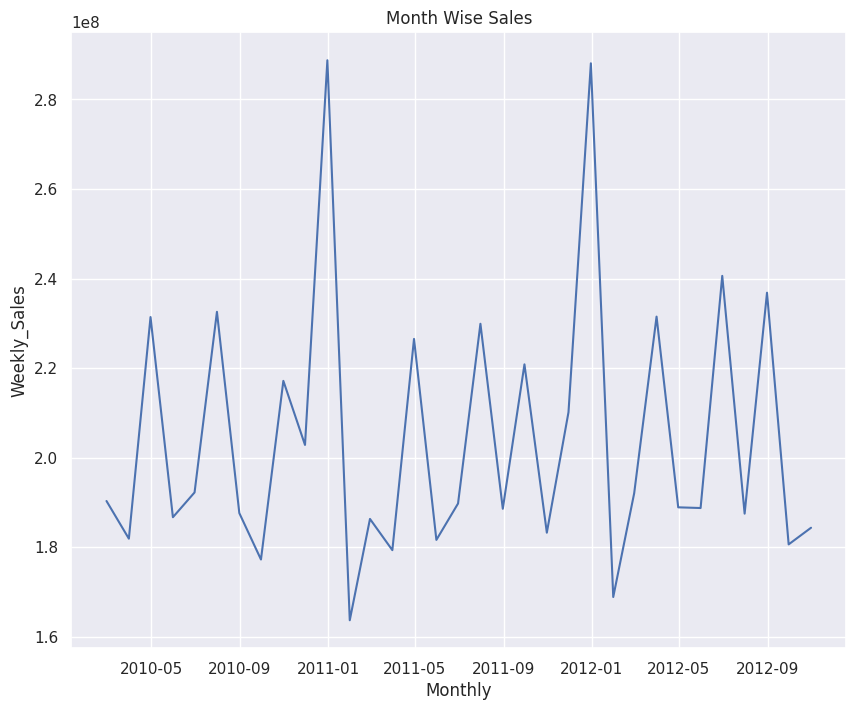

In [23]:
# Date and Weekly Sales
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df
monthly = df.groupby(pd.Grouper(key='Date', freq='1ME')).sum()
monthly = monthly.reset_index()
monthly = df.resample('ME', on='Date').sum().reset_index()
plt.figure(figsize=(10,8))
plt.plot(monthly['Date'], monthly['Weekly_Sales'])

plt.title('Month Wise Sales')
plt.xlabel('Monthly')
plt.ylabel('Weekly_Sales')
plt.show()

In [24]:
# conclusion: Yes, the weekly sales show a seasonal trend.
# The sales are higher during the holiday season,
# which could be due to increased consumer spending during that time.

## Does temperature affect the weekly sales in any manner?

In [25]:
bins=[-2.06,20,40,60,80,100.14]
labels =['< 20','From 20 To 40','From 40 To 60','From 60 To 80','> 80']
TemperatureCategory = pd.cut(df['Temperature'], bins, labels = labels)
TemperatureCategory

,Temperature
0,From 40 To 60
1,From 20 To 40
2,From 20 To 40
3,From 40 To 60
4,From 40 To 60
...,...
6430,From 60 To 80
6431,From 60 To 80
6432,From 40 To 60
6433,From 40 To 60


In [26]:
df['TemperatureCategory'] = TemperatureCategory
df.head()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,TemperatureCategory
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,From 40 To 60
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,From 20 To 40
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,From 20 To 40
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,From 40 To 60
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,From 40 To 60


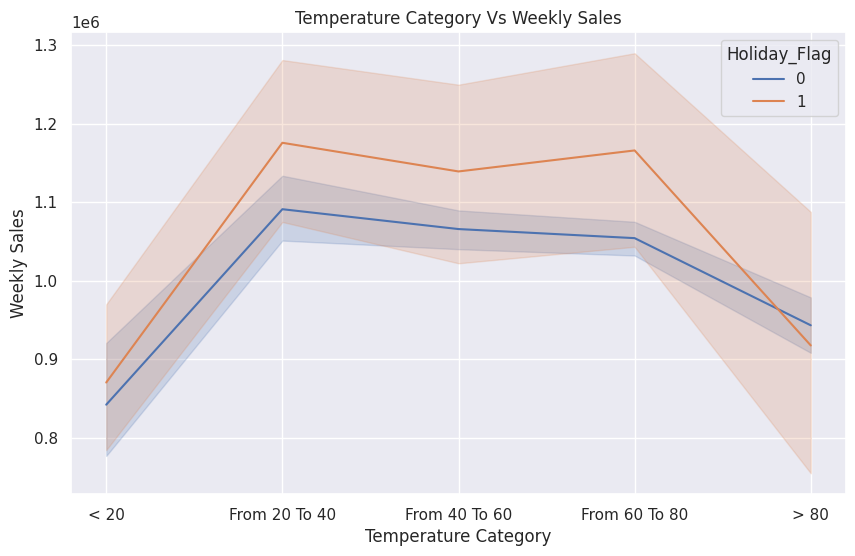

In [27]:
# line plot with hue = holiday flag

plt.figure(figsize=(10, 6))
sns.lineplot(x='TemperatureCategory', y='Weekly_Sales', hue='Holiday_Flag', data=df)
plt.title('Temperature Category Vs Weekly Sales')
plt.xlabel('Temperature Category')
plt.ylabel('Weekly Sales')
plt.show()

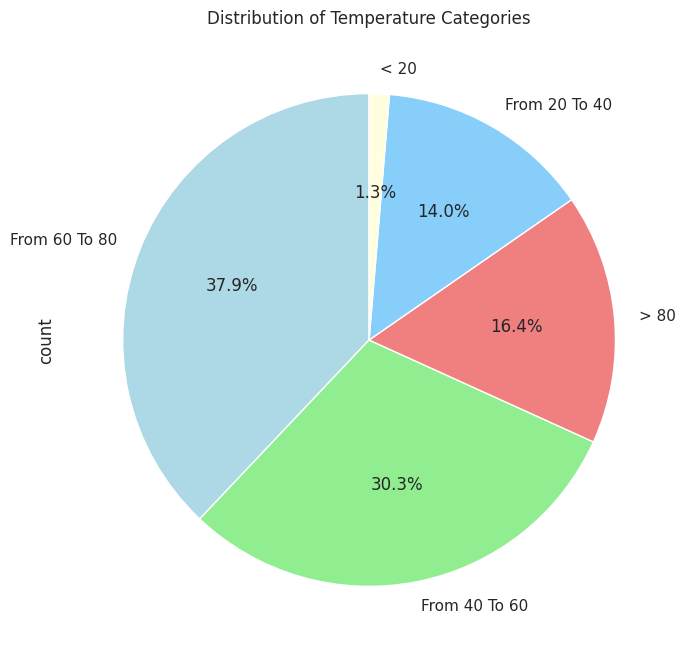

In [28]:
# pie plot
plt.figure(figsize=(8, 8))
df['TemperatureCategory'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightgreen', 'lightcoral', 'lightskyblue', 'lightyellow'])
plt.title('Distribution of Temperature Categories')
plt.show()

In [29]:
# conclusion: The line plot shows that there is a general trend of increasing weekly sales as the temperature increases.
# The line plot also shows that there is a higher sales during the holiday season.

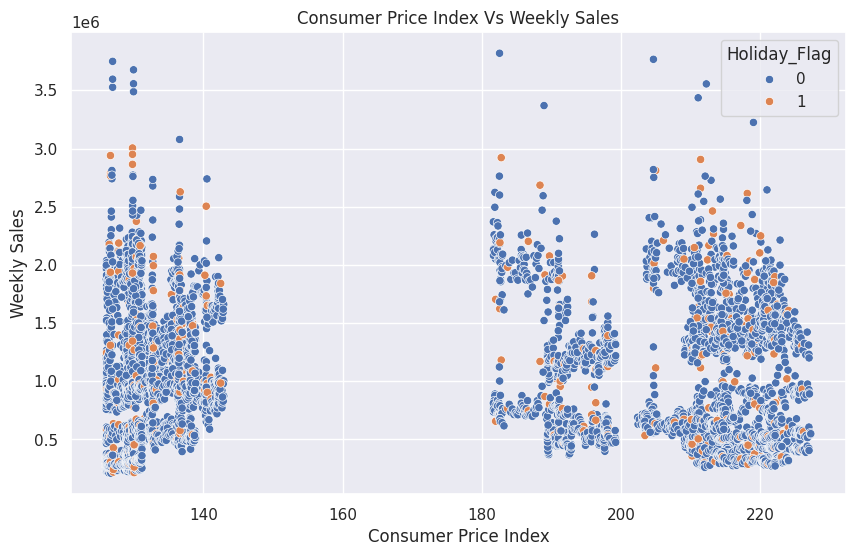

In [30]:
# How is the Consumer Price index affecting the weekly sales of various stores?
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CPI', y='Weekly_Sales', hue='Holiday_Flag', data=df)
plt.title('Consumer Price Index Vs Weekly Sales')
plt.xlabel('Consumer Price Index')
plt.ylabel('Weekly Sales')
plt.show()

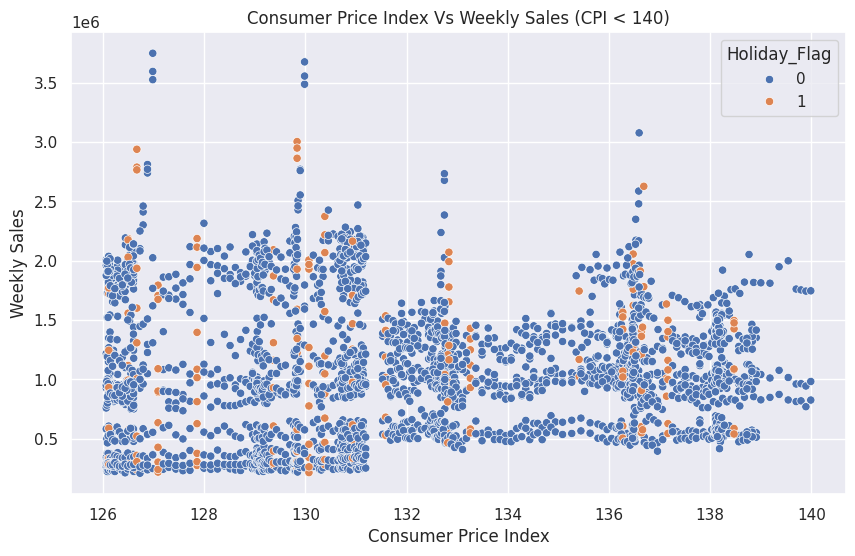

In [31]:
plt.figure(figsize=(10, 6))
data = df[df['CPI'] < 140]
sns.scatterplot(x='CPI', y='Weekly_Sales', hue='Holiday_Flag', data=data)
plt.title('Consumer Price Index Vs Weekly Sales (CPI < 140)')
plt.xlabel('Consumer Price Index')
plt.ylabel('Weekly Sales')
plt.show()


In [32]:
CPILess140 = len(data['CPI'])
CPILess140

2954

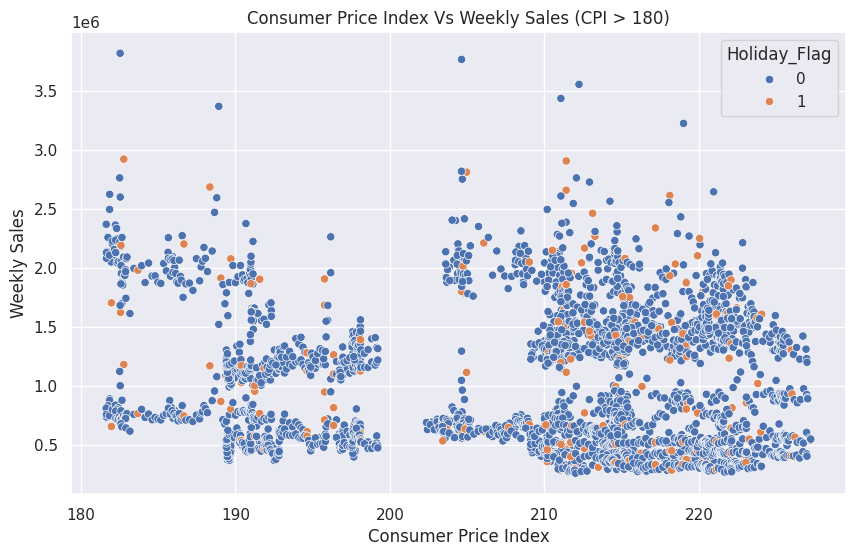

In [33]:
plt.figure(figsize=(10, 6))
data = df[df['CPI'] > 180]
sns.scatterplot(x='CPI', y='Weekly_Sales', hue='Holiday_Flag', data=data)
plt.title('Consumer Price Index Vs Weekly Sales (CPI > 180)')
plt.xlabel('Consumer Price Index')
plt.ylabel('Weekly Sales')
plt.show()


In [34]:
CPIGreater180 = len(data['CPI'])
CPIGreater180

3289

In [35]:
if CPILess140 > CPIGreater180:
    print("There are more data points with CPI less than 140. Difference is", CPILess140 - CPIGreater180)
else:
    print("There are more data points with CPI greater than 180. Difference is", CPIGreater180 - CPILess140)


There are more data points with CPI greater than 180. Difference is 335


In [36]:
# conclusion: The Majority of sales have a CPI greater than 180 , In other words Most of the sales have a CPI greater than the mean which is 185.

## Q5 Top performing stores according to the historical data

In [37]:
monthly = df.groupby(['Store', pd.Grouper(key='Date', freq='1ME')])['Weekly_Sales'].sum().reset_index()
print(monthly.head())
print(monthly.tail())

   Store       Date  Weekly_Sales
0      1 2010-02-28    6307344.10
1      1 2010-03-31    5871293.98
2      1 2010-04-30    7422801.92
3      1 2010-05-31    5929938.64
4      1 2010-06-30    6084081.46
      Store       Date  Weekly_Sales
1480     45 2012-06-30    4049712.68
1481     45 2012-07-31    3042463.41
1482     45 2012-08-31    3633793.89
1483     45 2012-09-30    2905011.08
1484     45 2012-10-31    2946326.39


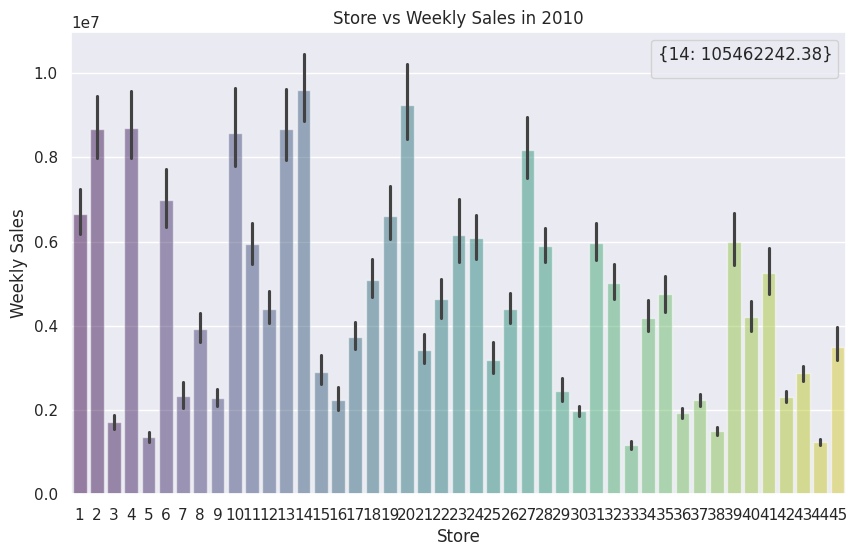

In [38]:
# plot 2010 years sales of various stores in bar plot
plt.figure(figsize=(10, 6))
data = monthly[monthly['Date'].dt.year == 2010]
sns.barplot(x='Store', y='Weekly_Sales', data=data, palette='viridis',color='red', alpha=0.5)
monthlySalesByStore = data.groupby('Store')['Weekly_Sales'].sum()
monthlySalesByStore2010 = monthlySalesByStore[monthlySalesByStore == monthlySalesByStore.max()]
plt.legend(title={int(monthlySalesByStore2010.index[0]) : float(monthlySalesByStore2010.values[0])}, loc='upper right')
plt.title('Store vs Weekly Sales in 2010')
plt.xlabel('Store')
plt.ylabel('Weekly Sales')
plt.show()

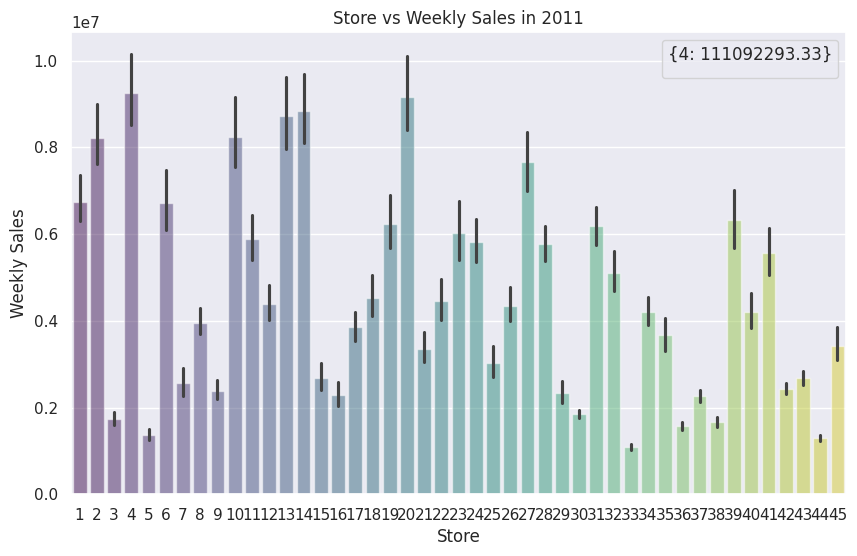

In [39]:
# plot 2011 years sales of various stores in bar plot
plt.figure(figsize=(10, 6))
data = monthly[monthly['Date'].dt.year == 2011]
sns.barplot(x='Store', y='Weekly_Sales', data=data, palette='viridis',color='red', alpha=0.5)
monthlySalesByStore = data.groupby('Store')['Weekly_Sales'].sum()
monthlySalesByStore2011 = monthlySalesByStore[monthlySalesByStore == monthlySalesByStore.max()]
plt.legend(title={int(monthlySalesByStore2011.index[0]) : float(monthlySalesByStore2011.values[0])}, loc='upper right')
plt.title('Store vs Weekly Sales in 2011')
plt.xlabel('Store')
plt.ylabel('Weekly Sales')
plt.show()

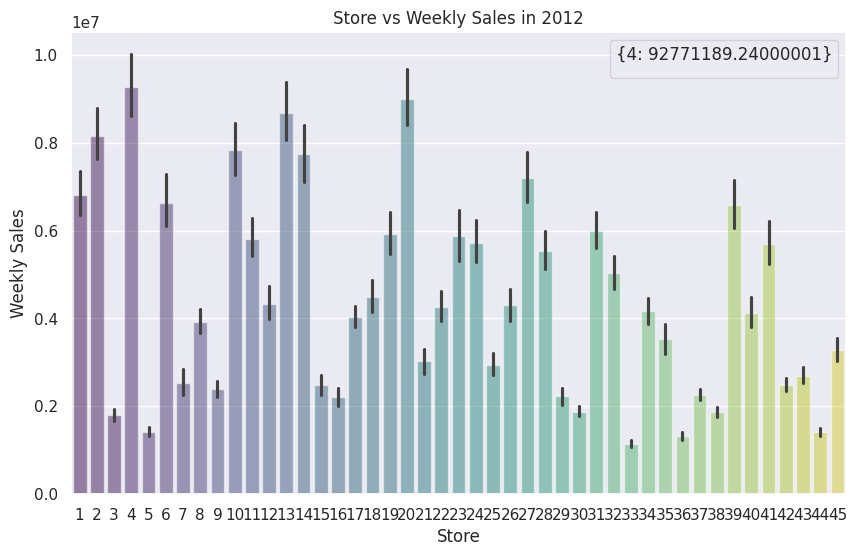

In [40]:
# plot 2012 years sales of various stores in bar plot
plt.figure(figsize=(10, 6))
data = monthly[monthly['Date'].dt.year == 2012]
sns.barplot(x='Store', y='Weekly_Sales', data=data, palette='viridis',color='red', alpha=0.5)
monthlySalesByStore = data.groupby('Store')['Weekly_Sales'].sum()
monthlySalesByStore2012 = monthlySalesByStore[monthlySalesByStore == monthlySalesByStore.max()]
plt.legend(title={int(monthlySalesByStore2012.index[0]) : float(monthlySalesByStore2012.values[0])}, loc='upper right')
plt.title('Store vs Weekly Sales in 2012')
plt.xlabel('Store')
plt.ylabel('Weekly Sales')
plt.show()

In [41]:
if monthlySalesByStore2010.values[0] > monthlySalesByStore2011.values[0] and monthlySalesByStore2010.values[0] > monthlySalesByStore2012.values[0]:
    print("Store", int(monthlySalesByStore2010.index[0]), "had the highest sales in 2010 with", float(monthlySalesByStore2010.values[0]), "weekly sales.")
elif monthlySalesByStore2011.values[0] > monthlySalesByStore2010.values[0] and monthlySalesByStore2011.values[0] > monthlySalesByStore2012.values[0]:
    print("Store", int(monthlySalesByStore2011.index[0]), "had the highest sales in 2011 with", float(monthlySalesByStore2011.values[0]), "weekly sales.")
elif monthlySalesByStore2012.values[0] > monthlySalesByStore2010.values[0] and monthlySalesByStore2012.values[0] > monthlySalesByStore2011.values[0]:
    print("Store", int(monthlySalesByStore2012.index[0]), "had the highest sales in 2012 with", float(monthlySalesByStore2012.values[0]), "weekly sales.")

Store 4 had the highest sales in 2011 with 111092293.33 weekly sales.


### Q6 The worst performing store, and how significant is the difference between the highest and lowest performing stores.

In [42]:
# The worst performing store, and how significant is the difference between the
# highest and lowest performing stores.

if monthlySalesByStore2010.values[0] < monthlySalesByStore2011.values[0] and monthlySalesByStore2010.values[0] < monthlySalesByStore2012.values[0]:
    print("Store", int(monthlySalesByStore2010.index[0]), "had the lowest sales in 2010 with", float(monthlySalesByStore2010.values[0]), "weekly sales.")
elif monthlySalesByStore2011.values[0] < monthlySalesByStore2010.values[0] and monthlySalesByStore2011.values[0] < monthlySalesByStore2012.values[0]:
    print("Store", int(monthlySalesByStore2011.index[0]), "had the lowest sales in 2011 with", float(monthlySalesByStore2011.values[0]), "weekly sales.")
elif monthlySalesByStore2012.values[0] < monthlySalesByStore2010.values[0] and monthlySalesByStore2012.values[0] < monthlySalesByStore2011.values[0]:
    print("Store", int(monthlySalesByStore2012.index[0]), "had the lowest sales in 2012 with", float(monthlySalesByStore2012.values[0]), "weekly sales.")

print("The difference between the highest and lowest performing stores in 2010 is", float(monthlySalesByStore2010.values[0]) - float(monthlySalesByStore2012.values[0]))

Store 4 had the lowest sales in 2012 with 92771189.24000001 weekly sales.
The difference between the highest and lowest performing stores in 2010 is 12691053.139999986


### Q2 Use predictive modeling techniques to forecast the sales for each store for the next 12 weeks.

In [ ]:
df_prophet = {}
for store_id in df['Store'].unique():
    store_df = df[df['Store'] == store_id].copy()
    store_df = store_df[['Date', 'Weekly_Sales']].rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
    store_df['ds'] = pd.to_datetime(store_df['ds'])
    store_df = store_df.sort_values(by='ds').reset_index(drop=True)
    df_prophet[store_id] = store_df

print(f"Prepared data for {len(df_prophet)} stores.")
print(df_prophet[1].head())

Prepared data for 45 stores.
          ds           y
0 2010-02-05  1643690.90
1 2010-02-12  1641957.44
2 2010-02-19  1611968.17
3 2010-02-26  1409727.59
4 2010-03-05  1554806.68


In [44]:
get_ipython().system('pip install prophet')

**Reasoning**:
Now that the `prophet` library is confirmed to be installed, the next logical step is to import the necessary modules, iterate through each store's prepared data, train a Prophet model for each, generate forecasts for the next 12 weeks, and consolidate these forecasts as per the instructions.



In [ ]:
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly
import logging
logging.getLogger('prophet').setLevel(logging.WARNING)

all_forecasts = []

unique_stores = df['Store'].unique()

for store_id in unique_stores:
    store_df_prophet = df_prophet[store_id]

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False, 
        daily_seasonality=False
    )
    model.fit(store_df_prophet)

    future = model.make_future_dataframe(periods=12, freq='W')

    forecast = model.predict(future)

    forecast['Store'] = store_id
    all_forecasts.append(forecast)


final_forecast_df = pd.concat(all_forecasts)

print("Forecasts generated for all stores. Displaying the first few rows of the consolidated forecast:")
print(final_forecast_df.head())

Forecasts generated for all stores. Displaying the first few rows of the consolidated forecast:
          ds         trend    yhat_lower    yhat_upper   trend_lower  \
0 2010-02-05  1.483589e+06  1.442406e+06  1.713182e+06  1.483589e+06   
1 2010-02-12  1.484651e+06  1.501478e+06  1.765939e+06  1.484651e+06   
2 2010-02-19  1.485714e+06  1.453595e+06  1.733889e+06  1.485714e+06   
3 2010-02-26  1.486776e+06  1.395353e+06  1.656646e+06  1.486776e+06   
4 2010-03-05  1.487839e+06  1.361233e+06  1.631056e+06  1.487839e+06   

    trend_upper  additive_terms  additive_terms_lower  additive_terms_upper  \
0  1.483589e+06    92034.886597          92034.886597          92034.886597   
1  1.484651e+06   145656.867700         145656.867700         145656.867700   
2  1.485714e+06   102501.834935         102501.834935         102501.834935   
3  1.486776e+06    35794.841492          35794.841492          35794.841492   
4  1.487839e+06      650.847575            650.847575            650.847575 

**Reasoning**:
The forecasts have been generated and stored in `final_forecast_df`. To effectively evaluate the model and gain insights into the forecasted sales, it's crucial to visualize these predictions. I will select a few stores to plot their historical data alongside the forecasted sales.



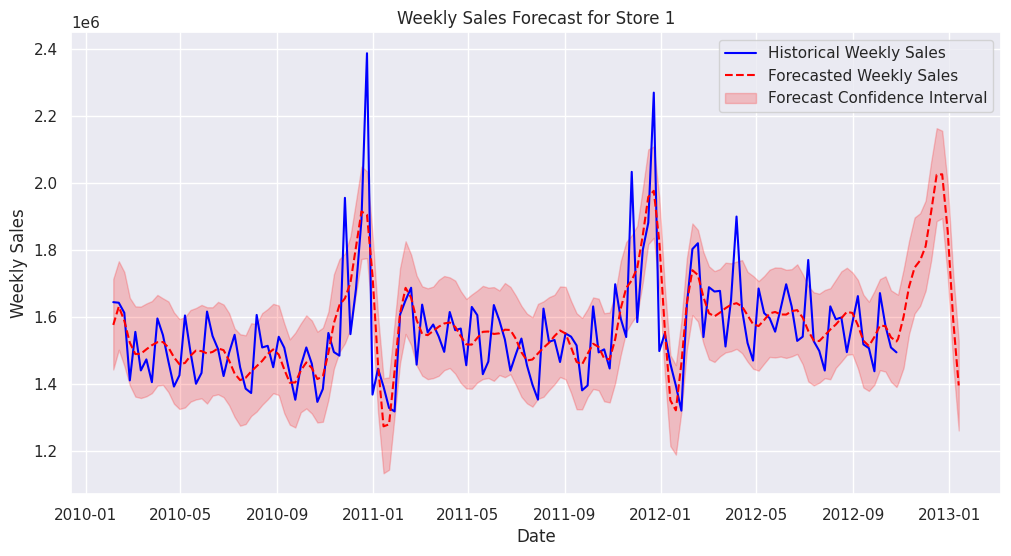

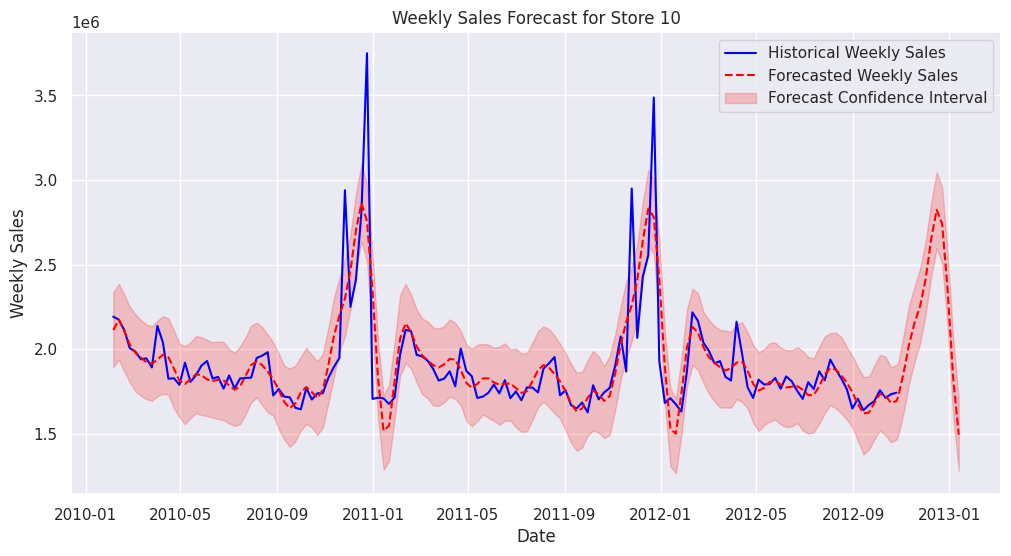

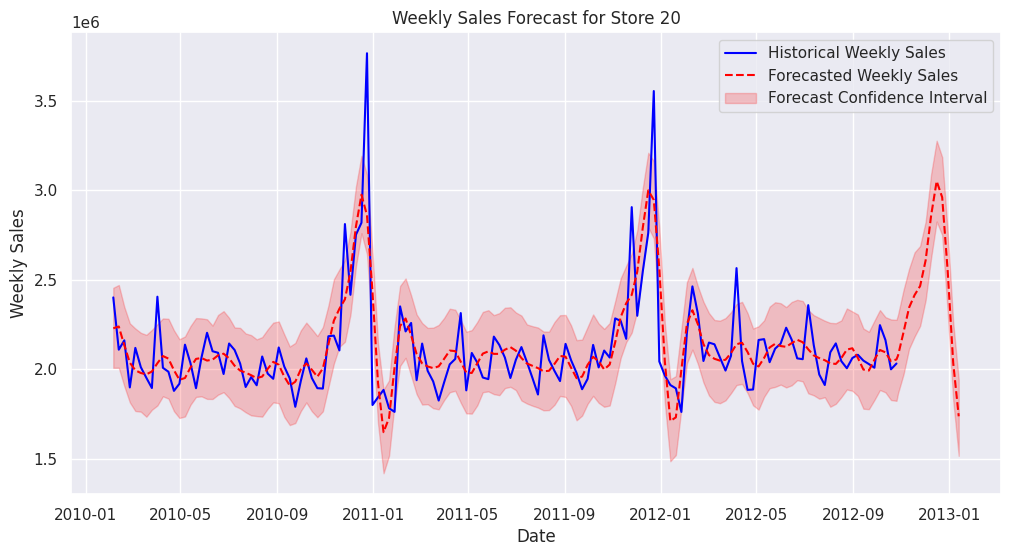

In [46]:
import matplotlib.pyplot as plt

# Select a few stores to visualize (e.g., Store 1, Store 10, Store 20)
selected_stores = [1, 10, 20]

for store_id in selected_stores:
    # Get original historical data for the store
    historical_df = df_prophet[store_id]

    # Get forecast data for the store
    forecast_df_store = final_forecast_df[final_forecast_df['Store'] == store_id]

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(historical_df['ds'], historical_df['y'], label='Historical Weekly Sales', color='blue')
    plt.plot(forecast_df_store['ds'], forecast_df_store['yhat'], label='Forecasted Weekly Sales', color='red', linestyle='--')
    plt.fill_between(
        forecast_df_store['ds'],
        forecast_df_store['yhat_lower'],
        forecast_df_store['yhat_upper'],
        color='red', alpha=0.2, label='Forecast Confidence Interval'
    )

    plt.title(f'Weekly Sales Forecast for Store {store_id}')
    plt.xlabel('Date')
    plt.ylabel('Weekly Sales')
    plt.legend()
    plt.grid(True)
    plt.show()
